<a href="https://colab.research.google.com/github/ritika1145/Vehicle-Price-Prediction-Model/blob/main/UsedVehiclePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uploading Datasets

In [1]:
#installing kaggle
! pip install kaggle --quiet

In [ ]:
#uploading kaggle file
from google.colab import files
files.upload()

In [3]:
#kaggle directory
!mkdir ~/.kaggle

In [4]:
#copy kaggle file
!cp kaggle.json ~/.kaggle/

In [ ]:
ls -ltr ~/.kaggle

In [6]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions list

In [ ]:
!kaggle datasets list

In [ ]:
!kaggle datasets download -d 'austinreese/craigslist-carstrucks-data'

In [ ]:
!unzip craigslist-carstrucks-data.zip

In [11]:
!rm craigslist-carstrucks-data.zip

In [ ]:
!ls

# EDA

In [13]:
#importing libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [14]:
df = pd.read_csv("vehicles.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [15]:
df.isnull().sum()


,0
id,0
url,0
region,0
region_url,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678


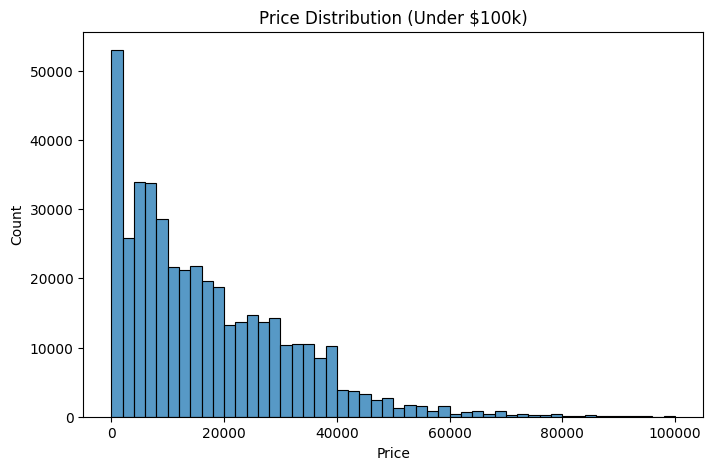

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['price'] < 100000]['price'], bins=50)
plt.title("Price Distribution (Under $100k)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# The price distribution is highly right-skewed, with most vehicles priced below $40,000.
# There is a large concentration of listings at very low prices, including values near $0,
# which may indicate missing or fake data.
# A small number of high-priced outliers are also present.
# General Trend as expected: As Price increases, the number of listed cars decreases
#                      Why?: the majority of used cars are affordable due to depreciation
#                            while high-priced or luxury vehicles are less common.

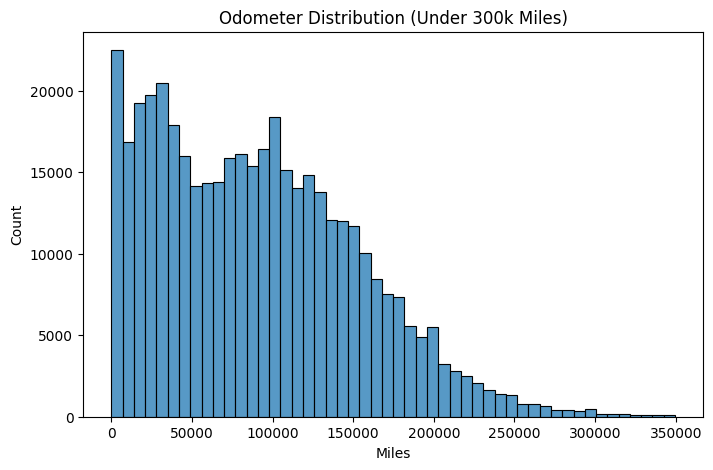

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['odometer'] < 350000]['odometer'], bins=50)

plt.title("Odometer Distribution (Under 300k Miles)")
plt.xlabel("Miles")
plt.ylabel("Count")
plt.show()

# The odometer distribution is right-skewed, with the majority of vehicles having mileage below 150,000 miles.
# There are also extreme values with very high mileage, indicating outliers
# General Trend as expected: As mileage increases, the number of listed cars decreases
#                      Why?: Cars are usually sold when they are still usable and valuable

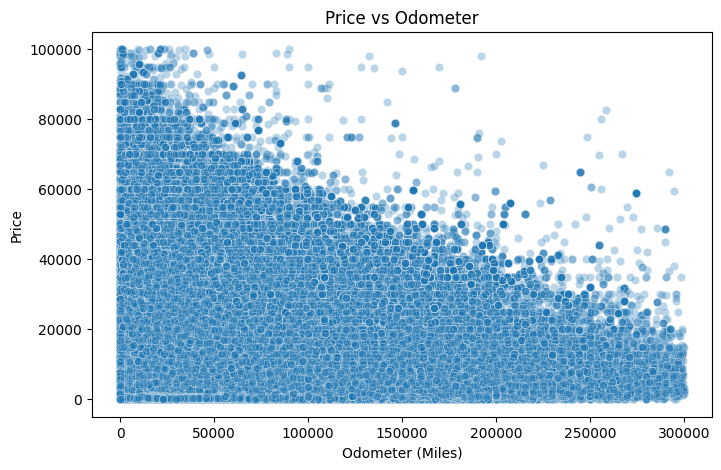

In [18]:
filtered = df[
    (df['price'] > 0) &
    (df['price'] < 100000) &
    (df['odometer'] < 300000)
]

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=filtered['odometer'],
    y=filtered['price'],
    alpha=0.3  # makes overlapping points visible
)

plt.title("Price vs Odometer")
plt.xlabel("Odometer (Miles)")
plt.ylabel("Price")
plt.show()

#The scatter plot shows a clear negative relationship between odometer reading and price, where vehicles with higher mileage tend to have lower prices.
# This reflects the effects of wear and depreciation over time, as higher mileage generally indicates more usage and reduced vehicle value.
# However, there is noticeable variation in price at similar mileage levels, suggesting that other factors such as manufacturer, year, and condition also influence price.

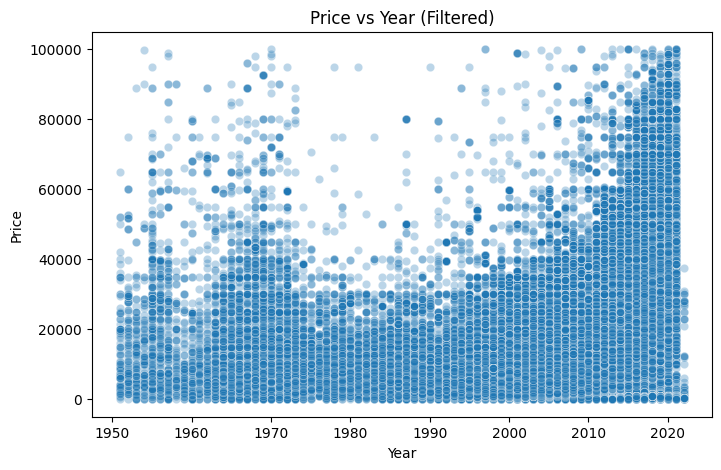

In [19]:
filtered = df[
    (df['price'] > 0) &
    (df['price'] < 100000) &
    (df['year'] > 1950)
]

plt.figure(figsize=(8,5))
sns.scatterplot(x=filtered['year'], y=filtered['price'], alpha=0.3)

plt.title("Price vs Year (Filtered)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

# There is a clear positive relationship between vehicle year and price from 1980, where newer cars tend to have higher prices.
# Older vehicles are generally less expensive, reflecting the effects of depreciation over time.
# There is a increase in older cars between 1960 to 1975, most likely due to them being considered vintage and thus having a higher price.
# noticeable variation in price within the same year, indicating that additional factors such as mileage, manufacturer, and condition also influence price.

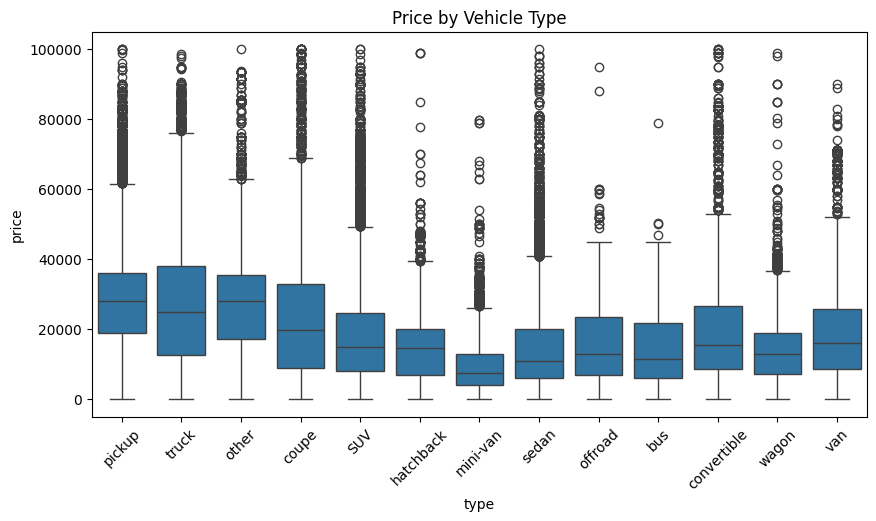

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='type',
    y='price',
    data=filtered
)

plt.title("Price by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

# Vehicle type has a clear impact on price, with larger vehicles such as pickup trucks and SUVs exhibiting higher median prices compared to smaller vehicles like sedans and hatchbacks.
# This reflects real-world differences in utility, demand, and production cost.
# Additionally, some vehicle types show a wide range of prices, indicating variability in features, condition, manufacturer and usage within each category.

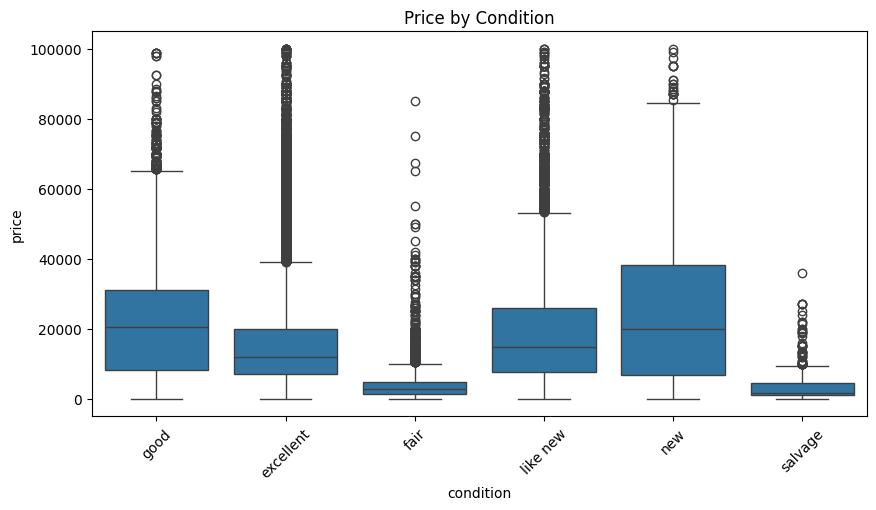

In [21]:
filtered = df[
    (df['price'] > 0) &
    (df['price'] < 100000)
]

plt.figure(figsize=(10,5))
sns.boxplot(x='condition', y='price', data=filtered)

plt.title("Price by Condition")
plt.xticks(rotation=45)
plt.show()

# Vehicle condition has a clear impact on price, with better-condition vehicles commanding higher prices.
# Listings categorized as "like new" or "excellent" tend to have higher median prices, while vehicles in poorer condition are significantly cheaper.
# This confirms that condition is an important factor influencing vehicle value.

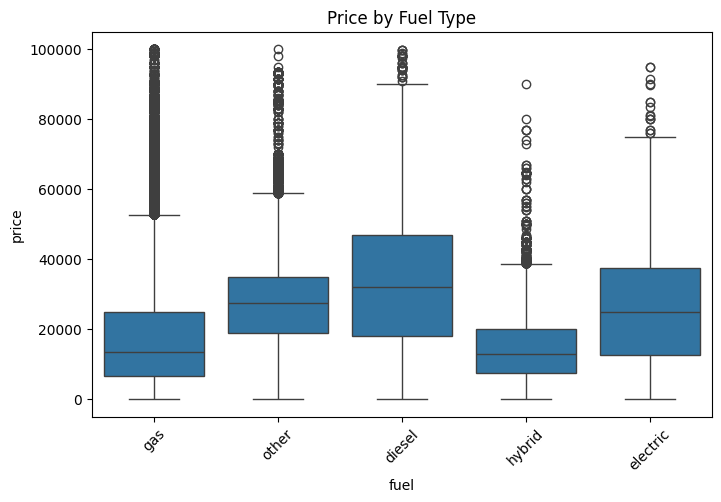

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='fuel',
    y='price',
    data=df[(df['price'] > 0) & (df['price'] < 100000)]
)

plt.title("Price by Fuel Type")
plt.xticks(rotation=45)
plt.show()

# Data Cleaning & Feature Engineering

In [23]:
# Remove columns that do not contribute to predicting price
df = df.drop([
    'id', 'url', 'region_url', 'image_url', 'description',
    'VIN', 'county', 'lat', 'long', 'posting_date',
    'region', 'state','manufacturer'
], axis=1, errors='ignore')

In [24]:
# Remove unrealistic price values:
# - very low values (likely invalid or placeholders)
# - extremely high outliers
df = df[(df['price'] > 1000) & (df['price'] < 100000)]


# Remove vehicles with unrealistic mileage
df = df[df['odometer'] < 300000]


# Remove older vehicles that behave like collectibles rather than typical used cars
df = df[df['year'] > 1980]

In [25]:
# Drop columns that are either too sparse or too noisy to be useful
df = df.drop(['size', 'model', 'paint_color'], axis=1, errors='ignore')

In [26]:
# Fill missing categorical values to avoid losing data
# "unknown" or "other" allows the model to still use these rows
df['condition'] = df['condition'].fillna('unknown')
df['drive'] = df['drive'].fillna('unknown')
df['type'] = df['type'].fillna('other')
df['title_status'] = df['title_status'].fillna('unknown')
df['transmission'] = df['transmission'].fillna('other')

In [27]:
# Convert fuel type into binary indicator columns (one-hot encoding manually)
# Each column represents whether the vehicle uses that fuel type
df['fuel'] = df['fuel'].fillna('other')

df['fuel_gas'] = (df['fuel'] == 'gas').astype(int)
df['fuel_diesel'] = (df['fuel'] == 'diesel').astype(int)
df['fuel_hybrid'] = (df['fuel'] == 'hybrid').astype(int)
df['fuel_electric'] = (df['fuel'] == 'electric').astype(int)

# Remove original fuel column since it is now encoded
df = df.drop('fuel', axis=1)

In [28]:
# Convert condition into an ordinal numeric scale
condition_map = {
    'new': 5,
    'like new': 4,
    'excellent': 3,
    'good': 2,
    'fair': 1,
    'salvage': 0,
    'unknown': -1
}
df['condition'] = df['condition'].map(condition_map)

In [29]:
# Extract numeric cylinder counts from text values (e.g., "6 cylinders" → 6)
# Then convert to numeric and fill missing values using the median
df['cylinders'] = df['cylinders'].astype(str)
df['cylinders'] = df['cylinders'].str.extract(r'(\d+)')
df['cylinders'] = df['cylinders'].astype(float)
df['cylinders'] = df['cylinders'].fillna(df['cylinders'].median())

In [30]:
# Create a new feature representing how old the vehicle is
import datetime
current_year = datetime.datetime.now().year
df['car_age'] = current_year - df['year']

# Remove invalid cases where age is zero or negative
df = df[df['car_age'] > 0]

In [31]:
# Create a feature representing how much the car is driven per year
# This helps capture usage intensity
df['miles_per_year'] = (df['odometer'] / df['car_age']).round(3)


# Drop original year since car_age captures the same information
df = df.drop('year', axis=1)

In [32]:
# Convert vehicle type into binary columns
# "other" is used as the baseline (all zeros)
df = pd.get_dummies(df, columns=['type'], drop_first=False, dtype=int)
df = df.drop('type_other', axis=1)

In [33]:
# Convert drivetrain type into binary columns
# "unknown" acts as the baseline category
df = pd.get_dummies(df, columns=['drive'], drop_first=False, dtype=int)
df = df.drop('drive_unknown', axis=1)

In [34]:
# Convert title status into binary columns
# "unknown" is used as the default baseline
df = pd.get_dummies(df, columns=['title_status'], drop_first=False, dtype=int)
df = df.drop('title_status_unknown', axis=1)

In [35]:
# Convert transmission type into binary columns
# "other" is treated as the baseline category
df = pd.get_dummies(df, columns=['transmission'], drop_first=False, dtype=int)
df = df.drop('transmission_other', axis=1)

In [36]:
# Final check to ensure no missing values remain
df.isnull().sum().sort_values(ascending=False)

,0
price,0
condition,0
cylinders,0
odometer,0
fuel_gas,0
fuel_diesel,0
fuel_hybrid,0
fuel_electric,0
car_age,0
miles_per_year,0


In [37]:
df = df.rename(columns={'title_status_parts only': 'title_status_parts_only'})

ordered_cols = [

    # Core numeric features
    'condition',
    'cylinders',
    'odometer',

    # Engineered features
    'car_age',
    'miles_per_year',

    # Fuel
    'fuel_gas',
    'fuel_diesel',
    'fuel_hybrid',
    'fuel_electric',

    # Vehicle type
    'type_SUV',
    'type_bus',
    'type_convertible',
    'type_coupe',
    'type_hatchback',
    'type_mini-van',
    'type_offroad',
    'type_pickup',
    'type_sedan',
    'type_truck',
    'type_van',
    'type_wagon',

    # Drive
    'drive_4wd',
    'drive_fwd',
    'drive_rwd',

    # Title status
    'title_status_clean',
    'title_status_lien',
    'title_status_missing',
    'title_status_parts_only',  # make sure renamed
    'title_status_rebuilt',
    'title_status_salvage',

    # Transmission
    'transmission_automatic',
    'transmission_manual',

    # Target LAST
    'price'
]

df = df[ordered_cols]

In [38]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [39]:
pd.set_option('display.max_columns', None)
df.head()

,condition,cylinders,odometer,car_age,miles_per_year,fuel_gas,fuel_diesel,fuel_hybrid,fuel_electric,type_SUV,type_bus,type_convertible,type_coupe,type_hatchback,type_mini-van,type_offroad,type_pickup,type_sedan,type_truck,type_van,type_wagon,drive_4wd,drive_fwd,drive_rwd,title_status_clean,title_status_lien,title_status_missing,title_status_parts_only,title_status_rebuilt,title_status_salvage,transmission_automatic,transmission_manual,price
27,2,8.0,57923.0,12.0,4826.917,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,33590
28,2,8.0,71229.0,16.0,4451.812,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,22590
29,2,8.0,19160.0,6.0,3193.333,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,39590
30,2,8.0,41124.0,9.0,4569.333,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,30990
31,3,6.0,128000.0,13.0,9846.154,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,15000


# Train/Validation/Test

In [40]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [41]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [42]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# data has been divided into:
# X_train, y_train → 80% (used to train the model)
# X_val, y_val     → 10% (used to tune/validate)
# X_test, y_test   → 10% (used for final evaluation)

In [43]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 291929
Validation: 36491
Test: 36492


# Model Training and Validation

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Model 1: Linear Regression (Baseline)

In [45]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

LinearRegression()

In [46]:
y_val_pred = lin_model.predict(X_val)

In [47]:
mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 5859.919983170863
RMSE: 8245.86290403283
R2: 0.6629891289853025


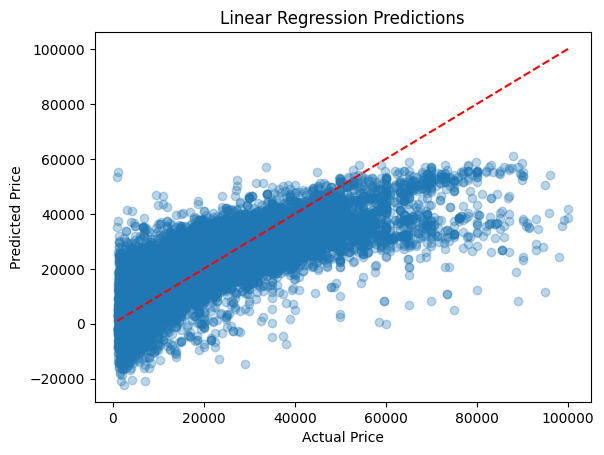

In [55]:
plt.scatter(y_val, y_val_pred, alpha=0.3)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red', linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression Predictions")
plt.show()

In [ ]:
# MAE: ~5860 → average error is about $5.8k
# RMSE: ~8246 → larger errors exist (outliers present)
# R²: ~0.66 → explains ~66% of price variation

# Decent baseline model
# Struggles with non-linear relationships (underfitting)
# Larger errors for cheaper cars (funnel pattern)
# Produces some unrealistic negative predictions

# Overall: useful baseline, but not strong enough for final model

Model 2: Ridge Regression

In [50]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [51]:
y_val_pred = ridge_model.predict(X_val)

In [52]:
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 5859.906401913001
RMSE: 8245.877732270712
R2: 0.662987916915222


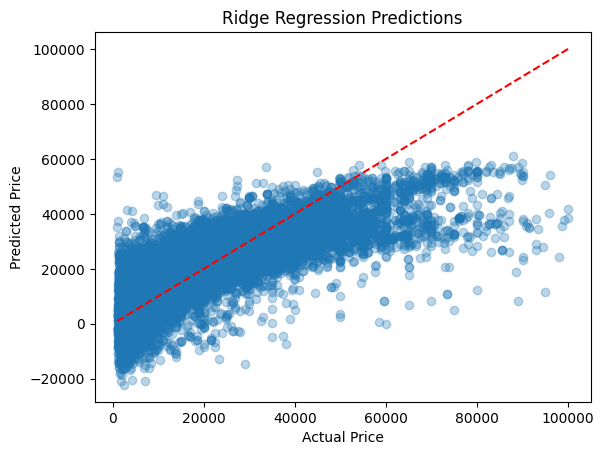

In [54]:
plt.scatter(y_val, y_val_pred, alpha=0.3)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red', linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression Predictions")
plt.show()

In [ ]:
# MAE: ~5860 → almost identical to Linear Regression
# RMSE: ~8246 → large errors still present
# R²: ~0.66 → no improvement in explained variance

# Very similar performance to Linear Regression
# Does not significantly improve predictions
# Still struggles with non-linear relationships

# Overall: no meaningful improvement over Linear Regression

Model 3: Decision Tree Regressor

In [57]:
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [58]:
y_val_pred = tree_model.predict(X_val)

In [59]:
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 4633.236014229111
RMSE: 6987.555856747618
R2: 0.7579961498430823


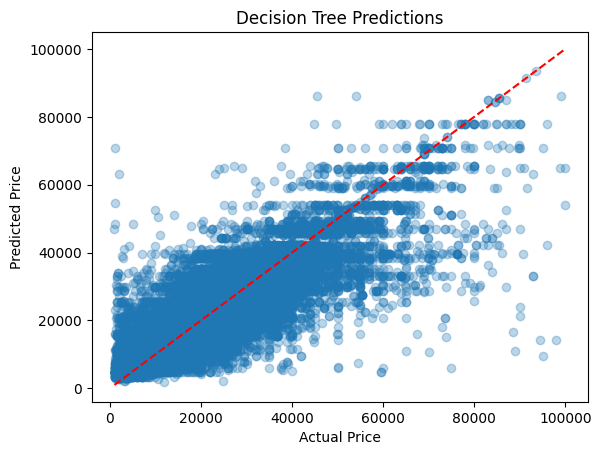

In [60]:
plt.scatter(y_val, y_val_pred, alpha=0.3)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red', linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree Predictions")
plt.show()

In [ ]:
# MAE: ~4633 → significantly lower than Linear/Ridge
# RMSE: ~6988 → fewer large errors
# R²: ~0.76 → strong improvement in explained variance

# Much better performance than Linear and Ridge
# Captures non-linear relationships effectively
# Reduced prediction error across most price ranges
# Some step-like prediction patterns (horizontal bands)

# Overall: strong improvement, but still not optimal

Model 4: Random Forest Regressor

In [64]:
rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=15,       # control overfitting
    random_state=42,
    n_jobs=-1   )

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [65]:
y_val_pred = rf_model.predict(X_val)

In [66]:
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 3659.030248256908
RMSE: 5793.144157151783
R2: 0.8336585964422287


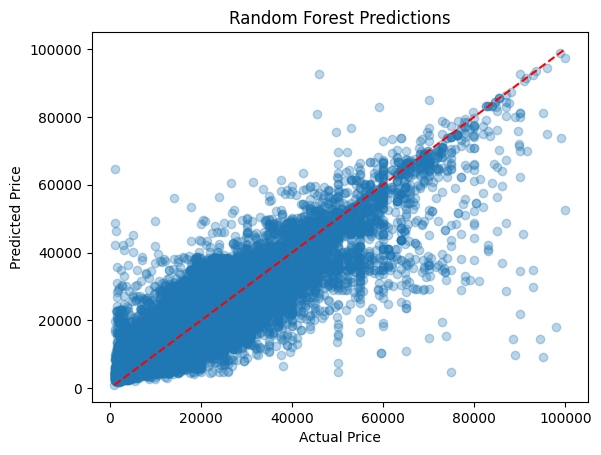

In [67]:
plt.scatter(y_val, y_val_pred, alpha=0.3)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red', linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Predictions")
plt.show()

In [ ]:
# MAE: ~3660 → significantly lower than all previous models
# RMSE: ~5793 → strong reduction in large errors
# R²: ~0.83 → explains most of price variation

# Best performing model so far
# Captures non-linear relationships effectively
# Much more accurate and stable predictions
# Smoother predictions compared to Decision Tree

# Overall: strongest model, good candidate for final model